<a href="https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/09_model_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[⬅ Back to the course index](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/00_START_HERE.ipynb) · **Notebook 09 of the course**


# 🩺 Notebook 09 — Optimizing your model: cleaner data & smarter search

> Two levers move a model's performance: the **data** you feed it and the **hyperparameters** you set.
> This notebook shows — honestly — how much each is worth, using proper cross-validation so we never
> fool ourselves. Spoiler: *cleaner data and better features usually beat clever tuning.*

**What you'll learn**
- Whether **cleaning the data** actually improves results — measured, not assumed (and *for which models*).
- How to **search** for good hyperparameters with `GridSearchCV`, `RandomizedSearchCV` and faster
  successive-halving — and how big a gain to realistically expect.
- How to run a quick, honest **model leaderboard** (a search over model *families*).
- When to reach for heavier tools (Bayesian optimisation, AutoML) — and when not to bother.

**⏱️ Time:** ≈55 min · **Prerequisites:** Notebooks 04–06 (features, models, evaluation)

### ⚙️ Run me first
Run the setup cell below once. (Same cell as every notebook — installs anything missing, sets the plot
style, and defines `load_csv` / the Drive cache.)

In [1]:
# === ⚙️  Workshop setup — run this cell first ===============================
# Works in Google Colab and in local Jupyter. Installs anything missing, sets a
# clean plotting style, and gives you helpers to load the data.
# (This cell is identical in every notebook of the course.)
import importlib.util, subprocess, sys, os, random, warnings
warnings.filterwarnings("ignore")

# --- reproducibility: everyone in the room gets the same numbers ---------------
RANDOM_STATE = 42
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)

# 📥 Where the workshop data comes from — already set up for you, nothing to do.
# The data downloads automatically the first time you need it. If you were given a
# different link, just paste it in place of the one below. These forms all work:
#   • a Google-Drive folder link      • a Drive / Dropbox / OneDrive file link
#   • a folder URL ending in "/"      • a link straight to a .zip
# Set it to "" if you would rather upload the CSVs by hand.
# (The data is not in the GitHub repo: it is real de-identified patient data covered
#  by a data use agreement and may not be redistributed openly.)
WORKSHOP_DATA_URL = os.environ.get(
    "WORKSHOP_DATA_URL",
    "https://drive.google.com/drive/folders/1y7CparhrqdlCAZq6xQlj8fZda394fniD")

def _ensure(pkgs):
    missing = [pip for mod, pip in pkgs.items() if importlib.util.find_spec(mod) is None]
    if missing:
        print("Installing:", *missing)
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing])
_ensure({"numpy":"numpy","pandas":"pandas","sklearn":"scikit-learn",
         "matplotlib":"matplotlib","seaborn":"seaborn","shap":"shap","xgboost":"xgboost"})

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
np.random.seed(RANDOM_STATE)          # seeds the legacy global np.random.* calls
RNG = np.random.default_rng(RANDOM_STATE)   # the modern generator — use this one
pd.set_option("display.max_columns", 120); pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5); plt.rcParams["figure.dpi"] = 110

# Every model, split and resample in this course passes random_state=RANDOM_STATE, so
# your numbers should match your neighbour's exactly. (Different library *versions* can
# still shift the last decimal — that is normal and not a mistake on your part.)

# --- data loading: works locally AND remembers your upload across notebooks -----
_CACHE = {"dir": "unset"}   # memo so we only touch Google Drive once per session

def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False

def _drive_cache():
    """In Google Colab, mount Drive ONCE and return a persistent folder. A file you
    upload in one notebook is saved here, so every other notebook opens it automatically
    — no re-uploading. Returns None outside Colab, or if you decline to connect Drive."""
    if _CACHE["dir"] != "unset":
        return _CACHE["dir"]
    result = None
    if _in_colab():
        try:
            from google.colab import drive
            if not os.path.ismount("/content/drive"):
                drive.mount("/content/drive")
            result = "/content/drive/MyDrive/sepsis_workshop_data"
            os.makedirs(result, exist_ok=True)
        except Exception:
            result = None
    _CACHE["dir"] = result
    return result

def _find(name):
    """Look for the file on disk. Deliberately does NOT touch Google Drive, so the normal
    path never triggers an authorisation popup."""
    for p in [name, f"data/{name}", f"../data/{name}", f"workshop/data/{name}"]:
        if os.path.exists(p):
            return p
    return None

def _find_in_drive(name):
    """Only used as a fallback, because it mounts Drive (and that means a popup)."""
    cache = _drive_cache()
    if cache:
        p = os.path.join(cache, name)
        if os.path.exists(p):
            return p
    return None

def _direct_url(u):
    """Turn an ordinary Google-Drive / Dropbox / OneDrive *share* link into one that a
    plain HTTP client can actually download, so you can paste the link you were given."""
    import re
    m = (re.search(r"drive\.google\.com/file/d/([\w-]+)", u)
         or re.search(r"drive\.google\.com/(?:open|uc)\?(?:export=\w+&)?id=([\w-]+)", u))
    if m:
        return f"https://drive.google.com/uc?export=download&id={m.group(1)}"
    if "dropbox.com" in u:
        return u.split("?")[0] + "?dl=1"
    if "sharepoint.com" in u or "1drv.ms" in u:
        return u + ("&" if "?" in u else "?") + "download=1"
    return u

def _fetch(url, dest):
    import urllib.request, shutil as _sh
    req = urllib.request.Request(_direct_url(url), headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=120) as r, open(dest, "wb") as f:
        _sh.copyfileobj(r, f)

_FOLDER = {"done": False}

def _gdrive_folder(name):
    """WORKSHOP_DATA_URL points at a Google-Drive *folder*: fetch it once with gdown
    (a folder cannot be downloaded with a plain HTTP request), then serve files from it."""
    dest = "_workshop_data"
    if not _FOLDER["done"]:
        _ensure({"gdown": "gdown"})
        import gdown
        print("⬇  fetching the workshop data from Google Drive (just once) …")
        gdown.download_folder(url=WORKSHOP_DATA_URL, output=dest, quiet=True, use_cookies=False)
        _FOLDER["done"] = True
    for root, _dirs, files in os.walk(dest):
        if name in files:
            return os.path.join(root, name)
    return None

def _try_download(name):
    """Fetch the data from WORKSHOP_DATA_URL, if one was configured."""
    u = (WORKSHOP_DATA_URL or "").strip()
    if not u:
        return None
    try:
        if "/drive/folders/" in u:
            return _gdrive_folder(name)
        if u.lower().split("?")[0].endswith(".zip"):
            import zipfile
            bundle = "_workshop_data.zip"
            if not os.path.exists(bundle):
                print("⬇  downloading the workshop data bundle …")
                _fetch(u, bundle)
            with zipfile.ZipFile(bundle) as z:      # flatten any folder inside the zip
                for member in z.namelist():
                    if os.path.basename(member) == name:
                        with z.open(member) as src, open(name, "wb") as dst:
                            dst.write(src.read())
                        return name
            print(f"  ({name} was not inside the bundle)")
            return None
        print(f"⬇  downloading {name} …")
        _fetch(u.rstrip("/") + "/" + name, name)
        return name
    except Exception as e:
        print(f"  (download failed: {e})")
        for leftover in (name, "_workshop_data.zip"):
            if os.path.exists(leftover) and os.path.getsize(leftover) == 0:
                os.remove(leftover)
        return None

def _cache_to_drive(name, data):
    cache = _drive_cache()
    if cache:
        dest = os.path.join(cache, name)
        data.to_csv(dest, index=False)
        print(f"  💾 saved to Google Drive ({dest}) — no need to fetch it again.")

def load_csv(name):
    """Load a data CSV: looks on disk, then downloads it from WORKSHOP_DATA_URL, then checks
    your Google-Drive cache, and only as a last resort asks you to upload it — in which case
    it saves a copy to Drive so you never have to upload it twice."""
    p = _find(name)                       # 1. already on disk?
    if p:
        print(f"✓ loaded {p}")
        return pd.read_csv(p)
    p = _try_download(name)               # 2. the built-in download link
    if p:
        print(f"✓ loaded {name}")
        return pd.read_csv(p)
    p = _find_in_drive(name)              # 3. a copy you saved on a previous run
    if p:
        print(f"✓ loaded {p}")
        return pd.read_csv(p)
    try:                                  # 4. last resort: upload it by hand
        from google.colab import files
        print(f"⤴  Upload {name} just once — I'll save it so the other notebooks open it automatically:")
        up = files.upload()
        fname = list(up.keys())[0]
        data = pd.read_csv(fname)
        _cache_to_drive(name, data)
        return data
    except Exception:
        raise FileNotFoundError(
            f"Could not find {name}. Either paste your download link into WORKSHOP_DATA_URL at "
            f"the top of this cell, or put the CSV next to this notebook / in a data/ folder."
        )


### 📥 Load the patient table
Same one-row-per-patient table as Notebook 05. We'll also set up the features `X`, the label `y`, the
patient `groups`, the class-imbalance weight `spw`, and a tiny `imp(...)` helper that bolts median
imputation in front of any model.

In [2]:
def build_patient_table(ts):
    """Aggregate the 4-hourly time-series into ONE row per ICU stay.
       (This is exactly what Notebook 04 teaches you to build.)"""
    df = ts.copy()
    # clean temperature: prefer Celsius; repair obvious Fahrenheit-entry errors; drop impossible
    tf = df["Temp_F"].where((df["Temp_F"] >= 90) & (df["Temp_F"] <= 110))
    tc = df["Temp_C"].where((df["Temp_C"] >= 25) & (df["Temp_C"] <= 45))
    df["Temp_C_clean"] = tc.fillna((tf - 32) * 5/9)
    # impossible vitals -> NaN, then forward/back-fill WITHIN each stay
    for c, lo, hi in [("HR",20,300),("SysBP",40,300),("MeanBP",20,220),("RR",3,80),("SpO2",30,100)]:
        df[c] = df[c].where((df[c] >= lo) & (df[c] <= hi))
    g = df.groupby("icustayid", group_keys=False)
    vit = ["HR","SysBP","MeanBP","RR","SpO2","Temp_C_clean"]
    df[vit] = g[vit].apply(lambda x: x.ffill().bfill())
    # winsorise skewed labs so one stray value can't define a min/max
    for c in ["Arterial_lactate","Creatinine","BUN","WBC_count","Platelets_count","INR","Glucose"]:
        lo, hi = df[c].quantile(0.01), df[c].quantile(0.99)
        df[c] = df[c].clip(lo, hi)
    tv = ["HR","SysBP","MeanBP","RR","SpO2","Temp_C_clean","GCS","Creatinine","BUN",
          "Arterial_lactate","WBC_count","Platelets_count","Potassium","Sodium",
          "Albumin","INR","Arterial_pH","Shock_Index","SOFA","SIRS","PaO2_FiO2","Hb"]
    grp = df.groupby("icustayid")
    f = {}
    f["age"]=grp["age"].first(); f["gender"]=grp["gender"].first()
    f["elixhauser"]=grp["elixhauser"].first(); f["re_admission"]=grp["re_admission"].first().astype(int)
    f["weight_kg"]=grp["Weight_kg"].median(); f["n_blocs"]=grp.size(); f["los_hours"]=grp["bloc"].max()*4
    f["mechvent_ever"]=grp["mechvent"].max(); f["vaso_max"]=grp["max_dose_vaso"].max()
    f["fluid_balance_last"]=grp["cumulated_balance"].last(); f["urine_total"]=grp["output_step"].sum()
    for c in tv:
        f[f"{c}_mean"]=grp[c].mean(); f[f"{c}_min"]=grp[c].min()
        f[f"{c}_max"]=grp[c].max();  f[f"{c}_last"]=grp[c].last()
    for c in ["Creatinine","Arterial_lactate","SOFA","Shock_Index","GCS"]:
        f[f"{c}_delta"]=grp[c].last()-grp[c].first()
    X = pd.DataFrame(f); X["morta_90"]=grp["morta_90"].max(); X["died_in_hosp"]=grp["died_in_hosp"].max()
    return X.reset_index()

def load_patients():
    p = _find("sepsis_patients.csv")
    if p:
        print(f"✓ loaded {p}"); return pd.read_csv(p)
    print("sepsis_patients.csv not found — building it from the time-series file…")
    return build_patient_table(load_csv("sepsis_timeseries.csv"))

In [3]:
patients = load_patients()

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier

DROP = ["icustayid", "morta_90", "died_in_hosp"]
X = patients.drop(columns=DROP)
y = patients["morta_90"].astype(int)
groups = patients["icustayid"]
spw = (y == 0).sum() / (y == 1).sum()          # class-imbalance weight for XGBoost
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def imp(*steps):
    """Wrap any estimator steps behind median imputation (a mini Pipeline)."""
    return Pipeline([("impute", SimpleImputer(strategy="median")), *steps])

print(f"X: {X.shape[0]} patients × {X.shape[1]} features   |   {y.mean():.1%} died   |   spw={spw:.2f}")

✓ loaded data/sepsis_patients.csv
X: 1696 patients × 104 features   |   18.2% died   |   spw=4.49


## 🧼 1 · Does cleaning the data actually help? (an honest test)

Everyone says *"clean your data."* Let's **measure** it. We build the patient features **twice** from the
raw time-series — once with **no cleaning at all**, once with the Notebook-02 recipe (fix impossible
vitals, repair the temperature unit errors, winsorise skewed labs) — and compare models with 5-fold
cross-validation. No cherry-picked single split.

In [4]:
# Build the SAME features two ways: raw (dirty) vs cleaned.
ts = load_csv("sepsis_timeseries.csv")
TV = ["HR","MeanBP","RR","SpO2","Creatinine","BUN","Arterial_lactate","WBC_count",
      "Platelets_count","Temp_C","Temp_F","Shock_Index","SOFA","GCS"]

def aggregate(d):
    g = d.groupby("icustayid")
    f = {"age": g["age"].first(), "elixhauser": g["elixhauser"].first()}
    for c in TV:
        f[f"{c}_mean"] = g[c].mean(); f[f"{c}_max"] = g[c].max(); f[f"{c}_min"] = g[c].min()
    out = pd.DataFrame(f); out["morta_90"] = g["morta_90"].max()
    return out.reset_index(drop=True)

# (a) DIRTY: aggregate the raw values, warts and all
dirty = aggregate(ts)

# (b) CLEAN: Notebook-02 recipe, then aggregate
d = ts.copy()
tf = d["Temp_F"].where(d["Temp_F"].between(90, 110)); tc = d["Temp_C"].where(d["Temp_C"].between(25, 45))
d["Temp_C"] = tc.fillna((tf - 32) * 5/9); d["Temp_F"] = tf.fillna(d["Temp_C"] * 9/5 + 32)
for c, lo, hi in [("HR",20,300),("MeanBP",20,220),("RR",3,80),("SpO2",30,100)]:
    d[c] = d[c].where(d[c].between(lo, hi))
    d[c] = d.groupby("icustayid")[c].ffill(); d[c] = d.groupby("icustayid")[c].bfill()
for c in ["Arterial_lactate","Creatinine","BUN","WBC_count","Platelets_count","Shock_Index"]:
    lo, hi = d[c].quantile(0.01), d[c].quantile(0.99); d[c] = d[c].clip(lo, hi)
clean = aggregate(d)

print("Look at what 'dirty' features actually contain:")
print(f"   Temp_F_max :  dirty = {dirty['Temp_F_max'].max():>8.0f} °F   ->   clean = {clean['Temp_F_max'].max():>6.1f} °F")
print(f"   Creatinine_max: dirty = {dirty['Creatinine_max'].max():>6.0f}      ->   clean = {clean['Creatinine_max'].max():>6.1f}")
print(f"   HR_min :      dirty = {dirty['HR_min'].min():>8.0f}      ->   clean = {clean['HR_min'].min():>6.1f}")

✓ loaded data/sepsis_timeseries.csv
Look at what 'dirty' features actually contain:
   Temp_F_max :  dirty =     3913 °F   ->   clean =  104.0 °F
   Creatinine_max: dirty =     75      ->   clean =   12.4
   HR_min :      dirty =        0      ->   clean =   29.2


Those `dirty` numbers are impossible — a temperature of nearly **4000 °F**, a heart rate of **0**.
They're unit typos and sensor artefacts. Now: do they actually hurt a model? It depends **which model**.

In [5]:
from sklearn.naive_bayes import GaussianNB

yv = dirty["morta_90"].astype(int).values
Xd = dirty.drop(columns="morta_90"); Xc = clean.drop(columns="morta_90")

def cv_auc(make_model, Xtab):
    return cross_val_score(make_model(), Xtab, yv, cv=cv5, scoring="roc_auc", n_jobs=-1)

# GaussianNB trusts each feature's distribution -> sensitive to impossible values.
# XGBoost is tree-based -> far more tolerant of outliers.
models = {
    "GaussianNB (sensitive)": lambda: imp(("clf", GaussianNB())),
    "XGBoost (robust)":       lambda: XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                                    subsample=0.8, colsample_bytree=0.8,
                                                    eval_metric="logloss", random_state=RANDOM_STATE),
}
rows = []
for name, mk in models.items():
    ad, ac = cv_auc(mk, Xd), cv_auc(mk, Xc)
    rows.append({"model": name, "DIRTY auc": ad.mean(), "CLEAN auc": ac.mean(), "gain": ac.mean()-ad.mean()})
compare = pd.DataFrame(rows)
compare.round(3)

,model,DIRTY auc,CLEAN auc,gain
0,GaussianNB (sensitive),0.744,0.763,0.019
1,XGBoost (robust),0.764,0.764,-0.000


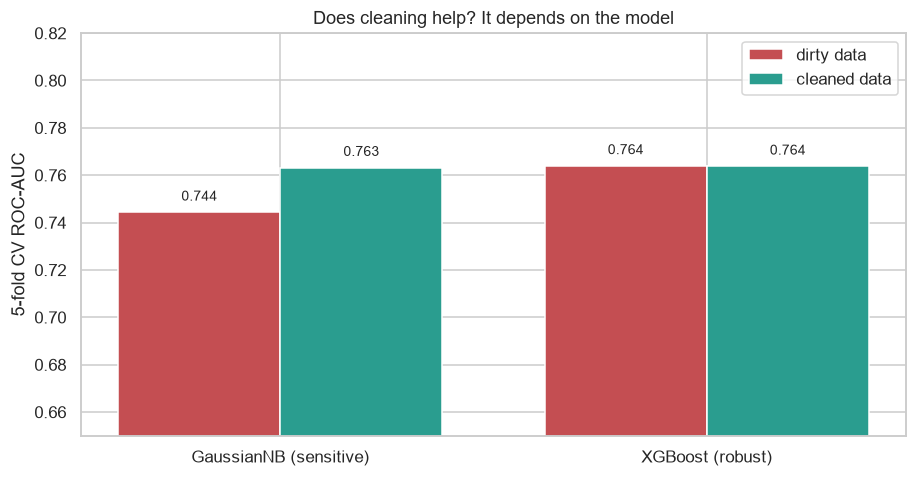

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
xpos = np.arange(len(compare)); w = 0.38
ax.bar(xpos - w/2, compare["DIRTY auc"], w, label="dirty data", color="#c44e52")
ax.bar(xpos + w/2, compare["CLEAN auc"], w, label="cleaned data", color="#2a9d8f")
for i, r in compare.iterrows():
    ax.text(i - w/2, r["DIRTY auc"]+0.005, f'{r["DIRTY auc"]:.3f}', ha="center", fontsize=9)
    ax.text(i + w/2, r["CLEAN auc"]+0.005, f'{r["CLEAN auc"]:.3f}', ha="center", fontsize=9)
ax.set_xticks(xpos); ax.set_xticklabels(compare["model"]); ax.set_ylabel("5-fold CV ROC-AUC")
ax.set_ylim(0.65, 0.82); ax.set_title("Does cleaning help? It depends on the model"); ax.legend()
plt.tight_layout(); plt.show()

> ### 🧠 Clinical takeaway — the honest version
> - For the **outlier-sensitive** model (Naive Bayes) cleaning gives a **clear, real gain** (see the table above — and larger still for other sensitive models).
> - For **robust tree models** (XGBoost) the AUC barely moves — trees just isolate the weird values.
>
> So is cleaning optional for tree models? **No.** A stable AUC hides three things cleaning still fixes:
> 1. **Your descriptive statistics** (Table 1, subgroup means, published figures) are *wrong* on dirty
>    data — a mean temperature pulled up by 4000 °F readings is not a finding, it's a bug.
> 2. **Individual predictions** can be driven by an artefact (a sensor glitch flagged as "high risk").
> 3. **Reproducibility** — cleaning reduces fold-to-fold variance, so your reported number is steadier.
>
> *Clean first, tune later.* Better data and better features beat hyperparameter tuning almost every time.

## 🎛️ 2 · Smarter search: tuning hyperparameters

Our Notebook-05 XGBoost used **hand-picked** settings (`max_depth=4`, `learning_rate=0.05`, …). Are they
best? Instead of guessing, we **search**, scoring every candidate with cross-validation:

- **`GridSearchCV`** — tries *every* combination on a grid. Thorough, but the cost explodes with each knob.
- **`RandomizedSearchCV`** — samples a fixed number of random combinations. You set the budget (`n_iter`);
  usually finds a near-best setting far faster. The practical default.
- **Successive halving** (`HalvingRandomSearchCV`) — starts many candidates on little data and keeps only
  the promising ones. Faster again.

In [7]:
# The hand-tuned default from Notebook 05 — our benchmark to beat.
def make_xgb(**kw):
    base = dict(eval_metric="logloss", scale_pos_weight=spw, random_state=RANDOM_STATE, n_jobs=-1)
    base.update(kw); return XGBClassifier(**base)

default_auc = cross_val_score(make_xgb(n_estimators=300, max_depth=4, learning_rate=0.05,
                                       subsample=0.8, colsample_bytree=0.8),
                              X, y, cv=cv5, scoring="roc_auc", n_jobs=-1).mean()
print(f"Hand-tuned default XGBoost:  CV AUC = {default_auc:.4f}")

Hand-tuned default XGBoost:  CV AUC = 0.7829


In [8]:
from sklearn.model_selection import GridSearchCV

# GridSearchCV: a small, explicit grid (2×2×2 = 8 combos × 5 folds = 40 fits)
grid = {
    "max_depth":     [3, 5],
    "learning_rate": [0.03, 0.1],
    "n_estimators":  [300, 500],
}
gs = GridSearchCV(make_xgb(subsample=0.8, colsample_bytree=0.8),
                  grid, scoring="roc_auc", cv=cv5, n_jobs=-1)
gs.fit(X, y)
print(f"GridSearchCV best CV AUC : {gs.best_score_:.4f}")
print("  best params:", gs.best_params_)

GridSearchCV best CV AUC : 0.7862
  best params: {'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 500}


In [9]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# RandomizedSearchCV: a wider space, sampled 25 times (cheaper than gridding it all)
param_dist = {
    "n_estimators":     randint(200, 600),
    "max_depth":        randint(2, 7),
    "learning_rate":    uniform(0.01, 0.19),
    "subsample":        uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
}
rs = RandomizedSearchCV(make_xgb(), param_dist, n_iter=25, scoring="roc_auc",
                        cv=cv5, random_state=RANDOM_STATE, n_jobs=-1)
rs.fit(X, y)
print(f"RandomizedSearchCV best CV AUC : {rs.best_score_:.4f}")
print("  best params:", {k: (round(v,3) if isinstance(v,float) else v) for k,v in rs.best_params_.items()})

RandomizedSearchCV best CV AUC : 0.7899
  best params: {'colsample_bytree': np.float64(0.683), 'learning_rate': np.float64(0.118), 'max_depth': 6, 'n_estimators': 390, 'subsample': np.float64(0.937)}


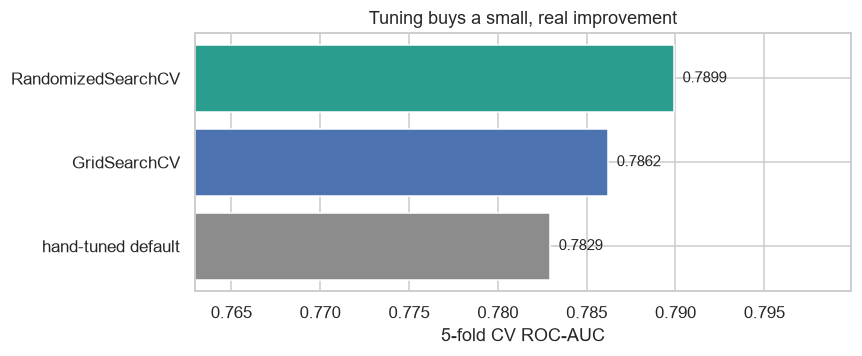

In [10]:
# How much did searching actually buy us?
scores = pd.Series({
    "hand-tuned default": default_auc,
    "GridSearchCV":       gs.best_score_,
    "RandomizedSearchCV": rs.best_score_,
}).sort_values()
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.barh(scores.index, scores.values, color=["#8c8c8c", "#4c72b0", "#2a9d8f"])
for i, v in enumerate(scores.values):
    ax.text(v + 0.0005, i, f"{v:.4f}", va="center", fontsize=10)
ax.set_xlim(default_auc - 0.02, max(scores.values) + 0.01)
ax.set_xlabel("5-fold CV ROC-AUC"); ax.set_title("Tuning buys a small, real improvement")
plt.tight_layout(); plt.show()

**Faster search — successive halving.** For bigger spaces, `HalvingRandomSearchCV` gives most candidates
a small budget and only "promotes" the survivors, so you explore more for the same compute:

```python
from sklearn.experimental import enable_halving_search_cv   # noqa
from sklearn.model_selection import HalvingRandomSearchCV
hs = HalvingRandomSearchCV(make_xgb(), param_dist, factor=3, scoring="roc_auc",
                           cv=cv5, random_state=RANDOM_STATE, n_jobs=-1).fit(X, y)
```

> ### 🧠 Clinical takeaway
> Tuning typically buys a **small** bump — a few thousandths to a couple hundredths of AUC. Real, but not
> magic. Search **last**, after the data work, and always score with cross-validation (and *group*-safe CV
> — `StratifiedGroupKFold` — the moment you tune on the raw per-block time-series). The number you report is
> only honest if the search never saw your final test set.

## 🏁 3 · A quick model leaderboard (searching over model *families*)

Before tuning one model to death, it's worth seeing how whole *families* compare on the same held-out
patients. This home-grown loop is what tools like *LazyPredict* do — an honest, ranked shortlist.

In [11]:
from time import perf_counter
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

def scaled(clf):  # impute -> scale -> model  (scaling helps the non-tree models)
    return Pipeline([("impute", SimpleImputer(strategy="median")),
                     ("scale", StandardScaler()), ("clf", clf)])

zoo = {
    "Logistic Reg.":   scaled(LogisticRegression(max_iter=2000, class_weight="balanced")),
    "KNN":             scaled(KNeighborsClassifier(n_neighbors=25)),
    "Random Forest":   imp(("clf", RandomForestClassifier(n_estimators=400, class_weight="balanced",
                                                          random_state=RANDOM_STATE, n_jobs=-1))),
    "Extra Trees":     imp(("clf", ExtraTreesClassifier(n_estimators=400, class_weight="balanced",
                                                        random_state=RANDOM_STATE, n_jobs=-1))),
    "HistGradBoost":   imp(("clf", HistGradientBoostingClassifier(random_state=RANDOM_STATE))),
    "XGBoost (tuned)": rs.best_estimator_,
}
rows = []
for name, model in zoo.items():
    t0 = perf_counter(); model.fit(X_tr, y_tr); dt = perf_counter() - t0
    auc = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])
    rows.append({"model": name, "test_AUC": auc, "fit_seconds": dt})
board = pd.DataFrame(rows).sort_values("test_AUC", ascending=False).reset_index(drop=True)
board.round(3)

Exception in thread Thread-4 (_readerthread):
Traceback (most recent call last):
  File "C:\Users\lolka\AppData\Local\Programs\Python\Python312\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "C:\Users\lolka\AppData\Local\Programs\Python\Python312\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\lolka\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "C:\Users\lolka\AppData\Local\Programs\Python\Python312\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x81 in position 120: character maps to <undefined>


,model,test_AUC,fit_seconds
0,Extra Trees,0.793,0.298
1,Random Forest,0.789,0.403
2,HistGradBoost,0.778,0.223
3,XGBoost (tuned),0.776,0.289
4,Logistic Reg.,0.772,0.023
5,KNN,0.759,0.010


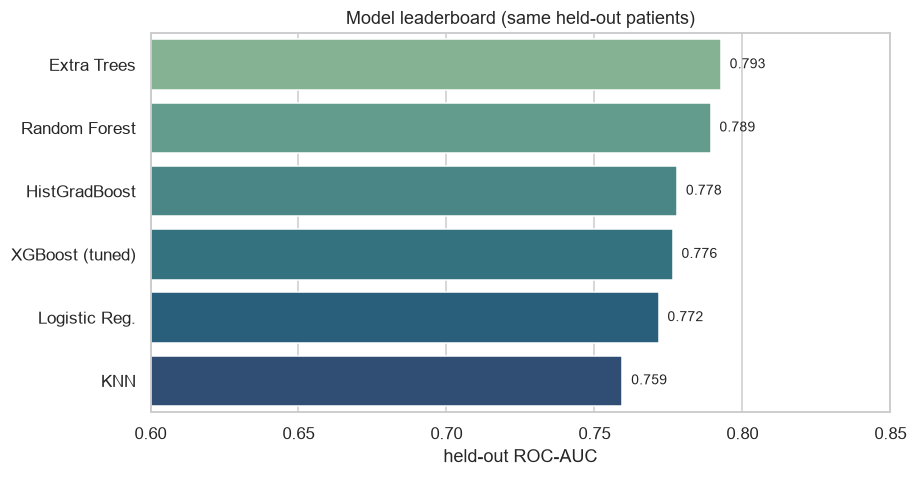

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
sns.barplot(data=board, y="model", x="test_AUC", hue="model", palette="crest", legend=False, ax=ax)
for i, v in enumerate(board["test_AUC"]):
    ax.text(v + 0.003, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlim(0.6, 0.85); ax.set_xlabel("held-out ROC-AUC"); ax.set_ylabel("")
ax.set_title("Model leaderboard (same held-out patients)")
plt.tight_layout(); plt.show()

> ### 🧠 Clinical takeaway
> Several very different algorithms land within a whisker of each other — typical for tabular clinical
> data. A leaderboard is the *right* first move: it tells you the **ceiling** you're working near, so you
> don't burn a day tuning a model that was never going to win. Then tune the front-runner.

### 🔭 Going further (one paragraph)
When a hand grid feels limiting, **Bayesian optimisation** (`Optuna`, `scikit-optimize`) spends its budget
where the search looks promising. Full **AutoML** frameworks (`AutoGluon`, `FLAML`, `PyCaret`) will try
many models *and* tune them for you in a few lines — handy for a strong baseline, but heavier to install and
easy to over-trust. On tabular ICU data none of these beats the fundamentals: **more, cleaner data and
better features**, validated with group-safe CV.

## ✏️ Your turn

### Exercise 1 — Tune a Random Forest
Use `RandomizedSearchCV` to tune a `RandomForestClassifier` (search `n_estimators`, `max_depth`,
`min_samples_leaf`, `max_features`). Does its best CV AUC catch the tuned XGBoost?

In [13]:
# TODO: build a RandomForest pipeline with imp(...), define a param_dist over
#       clf__n_estimators / clf__max_depth / clf__min_samples_leaf / clf__max_features,
#       run RandomizedSearchCV(n_iter=20, scoring='roc_auc', cv=cv5), print best_score_.


<details><summary>💡 Show solution</summary>

```python
from sklearn.ensemble import RandomForestClassifier
rf_pipe = imp(("clf", RandomForestClassifier(class_weight="balanced",
                                             random_state=RANDOM_STATE, n_jobs=-1)))
rf_dist = {
    "clf__n_estimators":     randint(200, 700),
    "clf__max_depth":        randint(3, 20),
    "clf__min_samples_leaf": randint(1, 20),
    "clf__max_features":     uniform(0.2, 0.8),
}
rf_search = RandomizedSearchCV(rf_pipe, rf_dist, n_iter=20, scoring="roc_auc",
                               cv=cv5, random_state=RANDOM_STATE, n_jobs=-1).fit(X, y)
print(f"Tuned RF  CV AUC = {rf_search.best_score_:.4f}   vs tuned XGB = {rs.best_score_:.4f}")
```
Usually the two land within ~0.01 AUC of each other — on tabular data the *family* matters less than the
data.
</details>

### Exercise 2 — Prove that cleaning steadies the estimate
For the **GaussianNB** model, print the 5-fold CV AUC **standard deviation** on the dirty vs the clean
features. Does cleaning reduce the fold-to-fold variance?

In [14]:
# TODO: cv_auc(lambda: imp(('clf', GaussianNB())), Xd).std()  vs  ... Xc ...


<details><summary>💡 Show solution</summary>

```python
gnb = lambda: imp(("clf", GaussianNB()))
print("GaussianNB CV-AUC std — dirty:", round(cv_auc(gnb, Xd).std(), 3),
      " | clean:", round(cv_auc(gnb, Xc).std(), 3))
```
The clean features give a **lower** standard deviation — a more reproducible, trustworthy estimate, even
where the *mean* AUC barely changes.
</details>

## ✅ Recap
- **Clean data > clever models.** Cleaning gave a clear gain for an outlier-sensitive model and steadier,
  more trustworthy results everywhere — even where a robust model's AUC barely moved. Clean anyway.
- **Search beats guessing, a little.** `GridSearchCV` (exhaustive), `RandomizedSearchCV` (budgeted), and
  `HalvingRandomSearchCV` (faster) tune hyperparameters — expect a *small*, real bump, scored with CV.
- **Leaderboard first, tune second.** Compare model families to find the ceiling, then tune the winner.
- **Order of impact:** more & cleaner data → better features → right model family → hyperparameters. Tune last.

## ➡️ Next
**Notebook 10 — 30 pandas tricks for medical researchers** (a punchy reference you'll reuse for years, now
with a bonus section on using **LLMs as a research copilot**). And if you're feeling adventurous,
**Notebook 11 — Reinforcement Learning for sepsis treatment** takes everything further: instead of
*predicting* the outcome, we try to *choose the treatment*. 🚀